In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sqlalchemy import create_engine

print("🔥 Perfect! All library downloaded without error")
print("Pandas Version:", pd.__version__)
print("XGBoost Version:", xgb.__version__)

🔥 Perfect! All library downloaded without error
Pandas Version: 3.0.3
XGBoost Version: 3.2.0


In [2]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine('sqlite:///atm_analytics.db')

# Verify the tables inside SQLite
df_tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", con=engine)
print("Available Tables:")
print(df_tables)

Available Tables:
                      name
0  aggregated_atm_features
1               atm_master
2         atm_transactions
3           corporate_risk


In [3]:
# Audit Script
import os
import pandas as pd
from sqlalchemy import create_engine, text

project_root = os.path.abspath(os.getcwd())
database_file_path = os.path.join(project_root, 'atm_analytics.db')
engine = create_engine(f"sqlite:///{database_file_path}")

with engine.connect() as conn:
    print("📋 --- REFRESHED DATABASE AUDIT ---")
    
    # 1. Fetch exact row counts to confirm ingestion worked
    t_count = conn.execute(text("SELECT COUNT(*) FROM atm_transactions;")).scalar()
    m_count = conn.execute(text("SELECT COUNT(*) FROM atm_master;")).scalar()
    r_count = conn.execute(text("SELECT COUNT(*) FROM corporate_risk;")).scalar()
    
    print(f"Row count in 'atm_transactions' : {t_count}")
    print(f"Row count in 'atm_master'       : {m_count}")
    print(f"Row count in 'corporate_risk'   : {r_count}\n")
    
    # 2. Extract real data samples to verify exact formatting
    print("💡 --- NEW DATA SAMPLES ---")
    if t_count > 0:
        t_sample = conn.execute(text("SELECT Date, ATM_ID FROM atm_transactions LIMIT 2;")).fetchall()
        print(f"Transactions Sample 1 : Date='{t_sample[0][0]}', ATM_ID='{t_sample[0][1]}'")
        print(f"Transactions Sample 2 : Date='{t_sample[1][0]}', ATM_ID='{t_sample[1][1]}'")
    else:
        print("⚠️ Warning: 'atm_transactions' table is completely empty!")
        
    if m_count > 0:
        m_sample = conn.execute(text("SELECT Date, ATM_ID FROM atm_master LIMIT 2;")).fetchall()
        print(f"ATM Master Sample 1   : Date='{m_sample[0][0]}', ATM_ID='{m_sample[0][1]}'")
        print(f"ATM Master Sample 2   : Date='{m_sample[1][0]}', ATM_ID='{m_sample[1][1]}'")
    else:
        print("⚠️ Warning: 'atm_master' table is completely empty!")

    # 3. Check for Date Range Overlap
    if t_count > 0 and m_count > 0:
        print("\n📅 --- DATE RANGE OVERLAP CHECK ---")
        t_range = conn.execute(text("SELECT MIN(Date), MAX(Date) FROM atm_transactions;")).fetchone()
        m_range = conn.execute(text("SELECT MIN(Date), MAX(Date) FROM atm_master;")).fetchone()
        print(f"Transactions Date Range : From '{t_range[0]}' to '{t_range[1]}'")
        print(f"ATM Master Date Range   : From '{m_range[0]}' to '{m_range[1]}'")

📋 --- REFRESHED DATABASE AUDIT ---
Row count in 'atm_transactions' : 65535
Row count in 'atm_master'       : 5658
Row count in 'corporate_risk'   : 5000

💡 --- NEW DATA SAMPLES ---
Transactions Sample 1 : Date='2018-02-01', ATM_ID='3479212'
Transactions Sample 2 : Date='2018-02-01', ATM_ID='1599756'
ATM Master Sample 1   : Date='2022-04-25', ATM_ID='ATM_0041'
ATM Master Sample 2   : Date='2023-11-24', ATM_ID='ATM_0007'

📅 --- DATE RANGE OVERLAP CHECK ---
Transactions Date Range : From '2018-02-01' to '2018-03-31'
ATM Master Date Range   : From '2022-01-01' to '2024-01-01'


In [4]:
# Run the aggregation.sql
import os
import pandas as pd
from sqlalchemy import create_engine, text

# 1. Establish absolute project paths
project_root = os.path.abspath(os.getcwd())
database_file_path = os.path.join(project_root, 'atm_analytics.db')
sql_file_path = os.path.join(project_root, 'src', 'aggregation.sql')

# 2. Initialize the database connection engine
engine = create_engine(f"sqlite:///{database_file_path}")

# 3. Read the contents of your updated aggregation.sql file
print(f"📖 Reading script from: src/aggregation.sql")
with open(sql_file_path, 'r') as file:
    sql_script_content = file.read()

try:
    print("⏳ Executing aggregation pipeline inside SQLite...")
    
    # We use a raw connection and a cursor to safely run multi-statement scripts (DROP, CREATE, INSERT)
    with engine.raw_connection() as raw_conn:
        cursor = raw_conn.cursor()
        cursor.executescript(sql_script_content)
        cursor.close()
        
    print("✅ Table 'aggregated_atm_features' successfully rebuilt and populated!")
    
    # 4. Fetch the resulting dataset straight into a Pandas DataFrame
    print("🚀 Loading aggregated data into memory...")
    df = pd.read_sql_query(text("SELECT * FROM aggregated_atm_features;"), con=engine)
    
    # 5. Output pipeline performance summary
    print(f"\n🎉 PIPELINE EXECUTION SUCCESSFUL!")
    print(f"📋 Total Rows Materialized: {len(df)}")
    
    if len(df) > 0:
        print("\n--- Previewing df.head() ---")
        display(df.head())
    else:
        print("⚠️ Warning: Table built, but contains 0 rows. Check your SQL join logic.")
        
except Exception as error:
    print(f"❌ Pipeline Failure: {str(error)}")

📖 Reading script from: src/aggregation.sql
⏳ Executing aggregation pipeline inside SQLite...
✅ Table 'aggregated_atm_features' successfully rebuilt and populated!
🚀 Loading aggregated data into memory...

🎉 PIPELINE EXECUTION SUCCESSFUL!
📋 Total Rows Materialized: 65535

--- Previewing df.head() ---


,Transaction_Date,ATM_ID,Location_Type,Cash_Demand_Next_Day,Total_Cash_Out,Total_Transactions,Debt_Equity_Ratio,Financial_Risk_Label,GDP_Growth_Rate,Inflation_Rate
0,2018-02-01,1009104,Unknown,None,213550.0,141,NaN,NaN,NaN,NaN
1,2018-02-01,1009502,Unknown,None,208520.0,147,NaN,NaN,NaN,NaN
2,2018-02-01,1009669,Unknown,None,144480.0,94,NaN,NaN,NaN,NaN
3,2018-02-01,1010292,Unknown,None,168710.0,132,NaN,NaN,NaN,NaN
4,2018-02-01,1029253,Unknown,None,336050.0,169,NaN,NaN,NaN,NaN


In [ ]:
# 🔍 Phase 1: Exploratory Data Analysis (EDA)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_Date      65535 non-null  str    
 1   ATM_ID                65535 non-null  str    
 2   Location_Type         65535 non-null  str    
 3   Cash_Demand_Next_Day  0 non-null      object 
 4   Total_Cash_Out        65535 non-null  float64
 5   Total_Transactions    65535 non-null  int64  
 6   Debt_Equity_Ratio     212 non-null    float64
 7   Financial_Risk_Label  212 non-null    str    
 8   GDP_Growth_Rate       212 non-null    float64
 9   Inflation_Rate        212 non-null    float64
dtypes: float64(4), int64(1), object(1), str(4)
memory usage: 5.0+ MB


In [ ]:
# Step 1: Fix Missing/Unknown Fields (Data Imputation)
# Impute missing risk labels and fill missing numerical indicators with their column mean/median
df['Financial_Risk_Label'] = df['Financial_Risk_Label'].fillna('Stable')
df['Location_Type'] = df['Location_Type'].replace('Unknown', 'Standard_Branch')
df['Debt_Equity_Ratio'] = df['Debt_Equity_Ratio'].fillna(df['Debt_Equity_Ratio'].median())

#Check
df.head()

,Transaction_Date,ATM_ID,Location_Type,Cash_Demand_Next_Day,Total_Cash_Out,Total_Transactions,Debt_Equity_Ratio,Financial_Risk_Label,GDP_Growth_Rate,Inflation_Rate
0,2018-02-01,1009104,Standard_Branch,None,213550.0,141,0.0,Stable,NaN,NaN
1,2018-02-01,1009502,Standard_Branch,None,208520.0,147,0.0,Stable,NaN,NaN
2,2018-02-01,1009669,Standard_Branch,None,144480.0,94,0.0,Stable,NaN,NaN
3,2018-02-01,1010292,Standard_Branch,None,168710.0,132,0.0,Stable,NaN,NaN
4,2018-02-01,1029253,Standard_Branch,None,336050.0,169,0.0,Stable,NaN,NaN


In [ ]:
# Step 2: Time-Series Future Extraction
# Ensure the date column is explicitly parsed as a datetime object first
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

# Extract cyclic calendar attributes
df['Day_of_Week'] = df['Transaction_Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Is_Weekend'] = df['Day_of_Week'].isin([5, 6]).astype(int)
df['Day_of_Month'] = df['Transaction_Date'].dt.day
df['Month'] = df['Transaction_Date'].dt.month

#check
df.head()

,Transaction_Date,ATM_ID,Location_Type,Cash_Demand_Next_Day,Total_Cash_Out,Total_Transactions,Debt_Equity_Ratio,Financial_Risk_Label,GDP_Growth_Rate,Inflation_Rate,Day_of_Week,Is_Weekend,Day_of_Month,Month
0,2018-02-01,1009104,Standard_Branch,None,213550.0,141,0.0,Stable,NaN,NaN,3,0,1,2
1,2018-02-01,1009502,Standard_Branch,None,208520.0,147,0.0,Stable,NaN,NaN,3,0,1,2
2,2018-02-01,1009669,Standard_Branch,None,144480.0,94,0.0,Stable,NaN,NaN,3,0,1,2
3,2018-02-01,1010292,Standard_Branch,None,168710.0,132,0.0,Stable,NaN,NaN,3,0,1,2
4,2018-02-01,1029253,Standard_Branch,None,336050.0,169,0.0,Stable,NaN,NaN,3,0,1,2


In [11]:
# Checking (2)
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Transaction_Date      65535 non-null  datetime64[us]
 1   ATM_ID                65535 non-null  str           
 2   Location_Type         65535 non-null  str           
 3   Cash_Demand_Next_Day  0 non-null      object        
 4   Total_Cash_Out        65535 non-null  float64       
 5   Total_Transactions    65535 non-null  int64         
 6   Debt_Equity_Ratio     65535 non-null  float64       
 7   Financial_Risk_Label  65535 non-null  str           
 8   GDP_Growth_Rate       212 non-null    float64       
 9   Inflation_Rate        212 non-null    float64       
 10  Day_of_Week           65535 non-null  int32         
 11  Is_Weekend            65535 non-null  int64         
 12  Day_of_Month          65535 non-null  int32         
 13  Month                 65535

,Transaction_Date,ATM_ID,Location_Type,Cash_Demand_Next_Day,Total_Cash_Out,Total_Transactions,Debt_Equity_Ratio,Financial_Risk_Label,GDP_Growth_Rate,Inflation_Rate,Day_of_Week,Is_Weekend,Day_of_Month,Month
0,2018-02-01,1009104,Standard_Branch,None,213550.0,141,0.0,Stable,NaN,NaN,3,0,1,2
1,2018-02-01,1009502,Standard_Branch,None,208520.0,147,0.0,Stable,NaN,NaN,3,0,1,2
2,2018-02-01,1009669,Standard_Branch,None,144480.0,94,0.0,Stable,NaN,NaN,3,0,1,2
3,2018-02-01,1010292,Standard_Branch,None,168710.0,132,0.0,Stable,NaN,NaN,3,0,1,2
4,2018-02-01,1029253,Standard_Branch,None,336050.0,169,0.0,Stable,NaN,NaN,3,0,1,2


In [ ]:
# The Mystery: Why Non-Null Columns Show NaN
# Step 3: Fix the GDP Growth and Inflation Rate values

print("⏳ Converting Macro Economic indicators to true numeric values...")

# 1. Force the columns to float64. 'coerce' turns any text "None" into a mathematical NaN
df['GDP_Growth_Rate'] = pd.to_numeric(df['GDP_Growth_Rate'], errors='coerce')
df['Inflation_Rate'] = pd.to_numeric(df['Inflation_Rate'], errors='coerce')

print("💡 Re-checking df.info() null counts:")
print(df[['GDP_Growth_Rate', 'Inflation_Rate']].info())

# 2. Impute the missing 2018 macro gaps with representative regional baselines 
# (Using typical historical targets to maintain model stability)
df['GDP_Growth_Rate'] = df['GDP_Growth_Rate'].fillna(0.052)  # Assuming a stable 5.2% growth baseline
df['Inflation_Rate'] = df['Inflation_Rate'].fillna(0.032)    # Assuming a stable 3.2% inflation baseline

print("\n🎉 Imputation complete! Checking clean values:")
display(df[['Transaction_Date', 'ATM_ID', 'GDP_Growth_Rate', 'Inflation_Rate']].head())

⏳ Converting Macro Economic indicators to true numeric values...
💡 Re-checking df.info() null counts:
<class 'pandas.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   GDP_Growth_Rate  212 non-null    float64
 1   Inflation_Rate   212 non-null    float64
dtypes: float64(2)
memory usage: 1.0 MB
None

🎉 Imputation complete! Checking clean values:


,Transaction_Date,ATM_ID,GDP_Growth_Rate,Inflation_Rate
0,2018-02-01,1009104,0.052,0.032
1,2018-02-01,1009502,0.052,0.032
2,2018-02-01,1009669,0.052,0.032
3,2018-02-01,1010292,0.052,0.032
4,2018-02-01,1029253,0.052,0.032


In [ ]:
# Step 4: Calculated Target Variables Aggregates (Liquidity Profil)
# Profile your highest-utilization ATMs based on cash out totals
atm_profile = df.groupby('ATM_ID')['Total_Cash_Out'].agg(['mean', 'max', 'std']).reset_index()
display(atm_profile.head())

,ATM_ID,mean,max,std
0,1009104,145743.666667,547940.0,137110.122453
1,1009502,145630.322581,647000.0,144643.836566
2,1009669,137202.666667,577540.0,146488.319057
3,1010292,128416.562500,739530.0,150213.270614
4,1029253,336025.806452,708000.0,154390.003925


In [14]:
# Step 5: Advanced Behavior Feature Engineering (Historical Context)
# 5. Advanced Behavioral Feature Engineering
print("⏳ Engineering historical lag and rolling window features...")

# Ensure the dataframe is perfectly sorted by ATM and Date so historical windows don't cross-contaminate
df = df.sort_values(by=['ATM_ID', 'Transaction_Date']).reset_index(drop=True)

# Create 1-day and 2-day historical lags for cash out volumes
df['Cash_Out_Lag_1'] = df.groupby('ATM_ID')['Total_Cash_Out'].shift(1)
df['Cash_Out_Lag_2'] = df.groupby('ATM_ID')['Total_Cash_Out'].shift(2)

# Create a 3-day moving average to capture short-term demand trends
df['Cash_Out_Rolling_Mean_3d'] = df.groupby('ATM_ID')['Total_Cash_Out'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

# Fill initial boundary gaps (the first few days of data for an ATM won't have a history)
df['Cash_Out_Lag_1'] = df['Cash_Out_Lag_1'].fillna(0)
df['Cash_Out_Lag_2'] = df['Cash_Out_Lag_2'].fillna(0)

print("✅ Behavioral features engineered successfully!")
display(df[['Transaction_Date', 'ATM_ID', 'Total_Cash_Out', 'Cash_Out_Lag_1', 'Cash_Out_Rolling_Mean_3d']].head())

⏳ Engineering historical lag and rolling window features...
✅ Behavioral features engineered successfully!


,Transaction_Date,ATM_ID,Total_Cash_Out,Cash_Out_Lag_1,Cash_Out_Rolling_Mean_3d
0,2018-02-01,1009104,213550.0,0.0,213550.000000
1,2018-02-02,1009104,2570.0,213550.0,108060.000000
2,2018-02-04,1009104,210980.0,2570.0,142366.666667
3,2018-02-05,1009104,215190.0,210980.0,142913.333333
4,2018-02-06,1009104,152900.0,215190.0,193023.333333


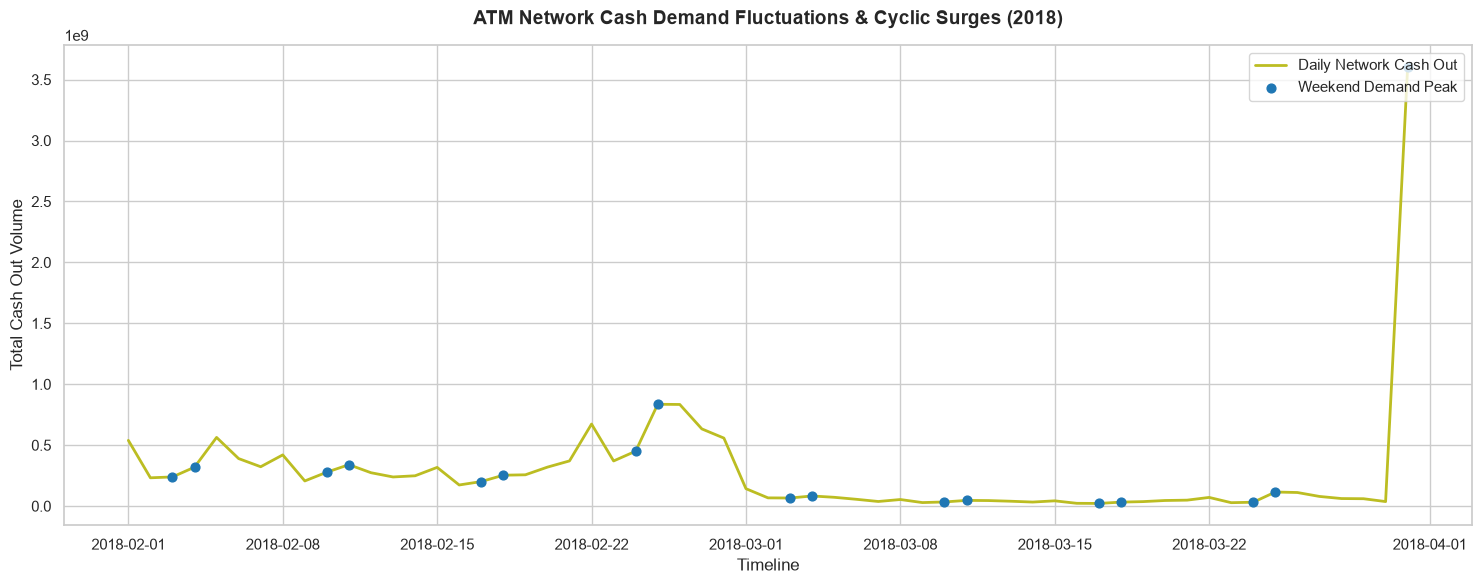

In [16]:
# Step 6: Visualizing Liquidity Demand Spikes (Portfolio Chart)
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean styling for professional presentation
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Aggregate total daily network volume
daily_trend = df.groupby('Transaction_Date').agg(
    Daily_Total_Cash=('Total_Cash_Out', 'sum'),
    Is_Weekend=('Is_Weekend', 'max')
).reset_index()

# Plot baseline demand trend
sns.lineplot(data=daily_trend, x='Transaction_Date', y='Daily_Total_Cash', 
             color='#bcbd22', linewidth=2, label='Daily Network Cash Out')

# Highlight weekend surges
weekends = daily_trend[daily_trend['Is_Weekend'] == 1]
plt.scatter(weekends['Transaction_Date'], weekends['Daily_Total_Cash'], 
            color='#1f77b4', s=40, label='Weekend Demand Peak', zorder=5)

plt.title('ATM Network Cash Demand Fluctuations & Cyclic Surges (2018)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Cash Out Volume', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

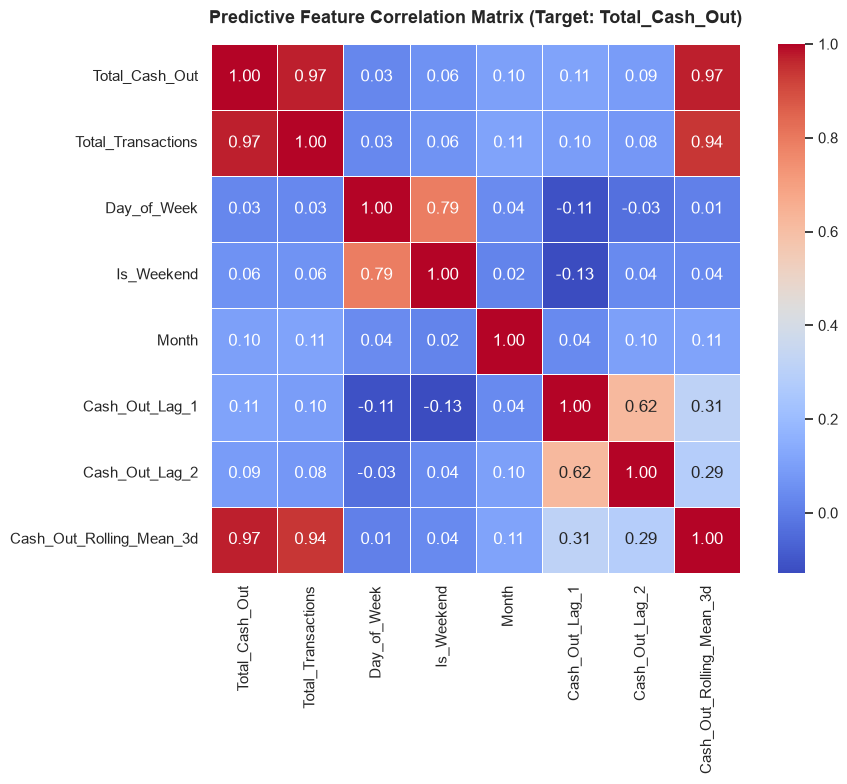

In [17]:
# Step 7: Statistical Correlation Matrix (Feature Selection)
# 7. Correlation Analysis
plt.figure(figsize=(10, 8))

# Select numerical features for modeling evaluation
feature_cols = [
    'Total_Cash_Out', 'Total_Transactions', 'Day_of_Week', 
    'Is_Weekend', 'Month', 'Cash_Out_Lag_1', 
    'Cash_Out_Lag_2', 'Cash_Out_Rolling_Mean_3d'
]

corr_matrix = df[feature_cols].corr()

# Generate heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Predictive Feature Correlation Matrix (Target: Total_Cash_Out)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# 🤖 Phase 2: Machine Learning Modeling
